# MVO & the Efficient Frontier

**pyportfolios.com tutorial T05** · SPY · TLT · GLD · VNQ · VEA · VWO, Jan 2015 – Dec 2024 · PyPortfolioOpt · Pandas · Matplotlib

Markowitz's 1952 insight — judge every asset by what it does to the *portfolio's*
risk and return, not by its own merits — is still the backbone of asset allocation.
In this notebook we

1. estimate expected returns and the covariance matrix from six real ETFs,
2. trace the long-only efficient frontier with PyPortfolioOpt,
3. solve the max-Sharpe and min-volatility portfolios (rf = 3%), and
4. meet mean–variance's famous weakness: extreme sensitivity to its inputs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pypfopt import EfficientFrontier, expected_returns, risk_models
from pypfopt.risk_models import CovarianceShrinkage

plt.rcParams["figure.figsize"] = (10, 5)
SEED, RF = 42, 0.03
TICKERS = ["SPY", "TLT", "GLD", "VNQ", "VEA", "VWO"]

## 1 · Data: six asset-class ETFs

US equities (SPY), long Treasuries (TLT), gold (GLD), REITs (VNQ), developed
international (VEA), and emerging markets (VWO) — a compact multi-asset menu
covering ten years that include a rate-hiking cycle, COVID, and two bull runs.

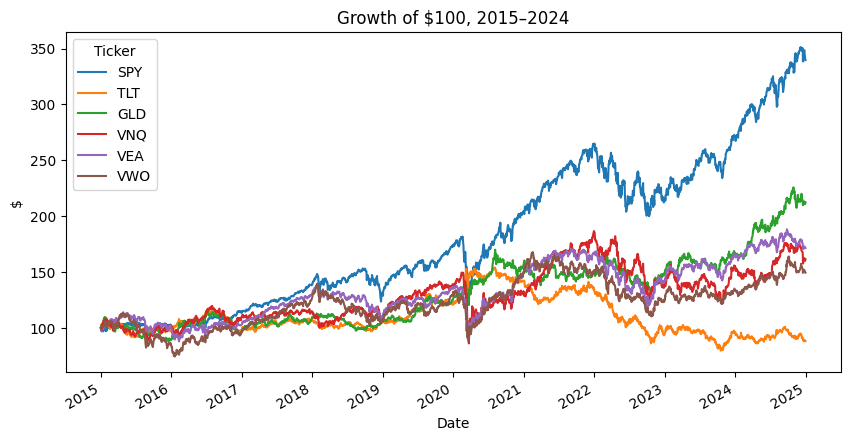

In [2]:
px = yf.download(TICKERS, start="2015-01-01", end="2025-01-01",
                 auto_adjust=True, progress=False)["Close"][TICKERS].dropna()
(px / px.iloc[0] * 100).plot(title="Growth of $100, 2015–2024"); plt.ylabel("$");

## 2 · The two inputs: μ and Σ

Mean–variance needs an expected-return vector and a covariance matrix. We use
the standard historical estimators — annualised geometric mean returns and the
annualised sample covariance — plus a Ledoit–Wolf shrunk covariance for
comparison later. **These estimates carry large errors, and MVO will amplify
them**; that is the lesson of section 6.

In [3]:
mu = expected_returns.mean_historical_return(px)   # CAGR per asset
S  = risk_models.sample_cov(px)                    # annualised covariance

cs = CovarianceShrinkage(px)
S_lw = cs.ledoit_wolf()
print(mu.round(4))
print(f"\nLedoit-Wolf shrinkage intensity delta = {cs.delta:.4f}")

Ticker
SPY    0.1303
TLT   -0.0125
GLD    0.0783
VNQ    0.0491
VEA    0.0554
VWO    0.0411
dtype: float64

Ledoit-Wolf shrinkage intensity delta = 0.0160


## 3 · The random-portfolio cloud and the frontier

2,000 random long-only portfolios (Dirichlet weights) show what's *attainable*;
the efficient frontier is its upper-left edge — for each target return, the
minimum-variance portfolio that reaches it.

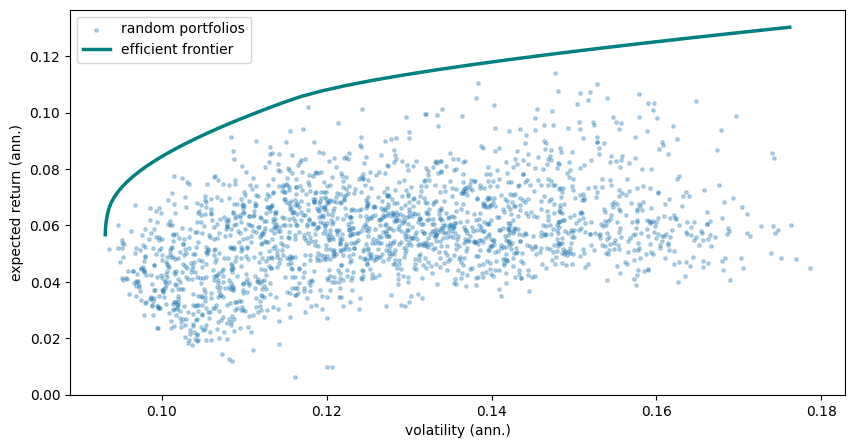

In [4]:
rng = np.random.default_rng(SEED)
w_rand = rng.dirichlet(np.ones(len(TICKERS)), size=2000)
rand_ret = w_rand @ mu.values
rand_vol = np.sqrt(np.einsum("ij,jk,ik->i", w_rand, S.values, w_rand))

ef = EfficientFrontier(mu, S)
ef.min_volatility()
ret_mv, vol_mv, _ = ef.portfolio_performance(risk_free_rate=RF)

targets = np.linspace(ret_mv, mu.max() * 0.9999, 40)
frontier = []
for t in targets:
    ef = EfficientFrontier(mu, S)          # fresh solver per target
    ef.efficient_return(target_return=t)
    f_ret, f_vol, _ = ef.portfolio_performance(risk_free_rate=RF)
    frontier.append((f_vol, f_ret))
frontier = np.array(frontier)

plt.scatter(rand_vol, rand_ret, s=6, alpha=0.3, label="random portfolios")
plt.plot(frontier[:, 0], frontier[:, 1], lw=2.5, color="teal", label="efficient frontier")
plt.xlabel("volatility (ann.)"); plt.ylabel("expected return (ann.)"); plt.legend();

## 4 · Max-Sharpe, min-vol, and the capital market line

With a risk-free rate the whole frontier collapses to one risky portfolio: the
**tangency (max-Sharpe) portfolio**. Every efficient investor holds it, levered
up or down along the capital market line (rf = 3%).

Expected annual return: 10.9%
Annual volatility: 12.1%
Sharpe Ratio: 0.65


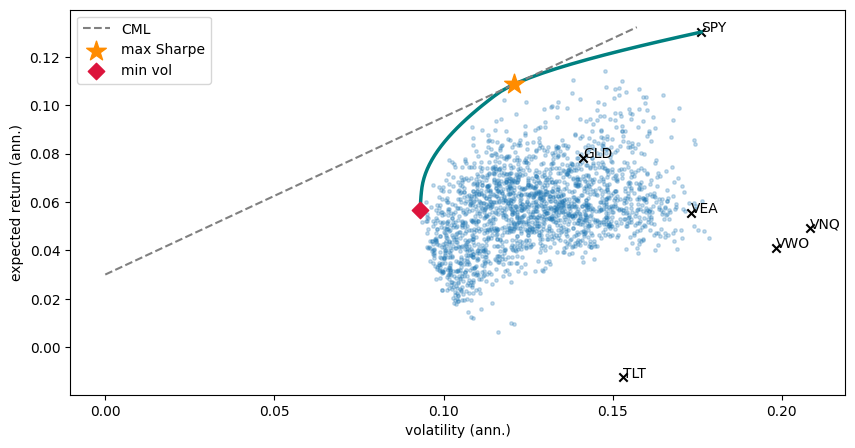

In [5]:
ef = EfficientFrontier(mu, S)
ef.max_sharpe(risk_free_rate=RF)
w_ms = pd.Series(ef.clean_weights())
ret_ms, vol_ms, sharpe_ms = ef.portfolio_performance(risk_free_rate=RF, verbose=True)

ef = EfficientFrontier(mu, S)
ef.min_volatility()
w_minvol = pd.Series(ef.clean_weights())
ret_minv, vol_minv, sharpe_minv = ef.portfolio_performance(risk_free_rate=RF)

cml_x = np.array([0, vol_ms * 1.3])
plt.scatter(rand_vol, rand_ret, s=6, alpha=0.25)
plt.plot(frontier[:, 0], frontier[:, 1], lw=2.5, color="teal")
plt.plot(cml_x, RF + sharpe_ms * cml_x, "--", color="grey", label="CML")
plt.scatter([vol_ms], [ret_ms], marker="*", s=220, color="darkorange", label="max Sharpe", zorder=5)
plt.scatter([vol_minv], [ret_minv], marker="D", s=70, color="crimson", label="min vol", zorder=5)
for t in TICKERS:
    plt.annotate(t, (np.sqrt(S.loc[t, t]), mu[t]))
plt.scatter(np.sqrt(np.diag(S)), mu, marker="x", color="k")
plt.xlabel("volatility (ann.)"); plt.ylabel("expected return (ann.)"); plt.legend();

## 5 · The weights — and the concentration problem

Look at what the optimiser actually holds. Max-Sharpe piles into the few assets
with the best in-sample Sharpe ratios and zeroes out the rest — a classic MVO
symptom: it treats noisy return estimates as gospel and maximises into their
errors ("error maximisation", Michaud 1989).

     max Sharpe  min vol
SPY      0.5843   0.2677
TLT      0.0000   0.3708
GLD      0.4158   0.2801
VNQ      0.0000   0.0000
VEA      0.0000   0.0814
VWO      0.0000   0.0000

max-Sharpe holds 2 of 6 assets  ->  effective N = 1.94

max Sharpe under Ledoit-Wolf covariance:
SPY    0.5863
TLT    0.0000
GLD    0.4137
VNQ    0.0000
VEA    0.0000
VWO    0.0000
dtype: float64


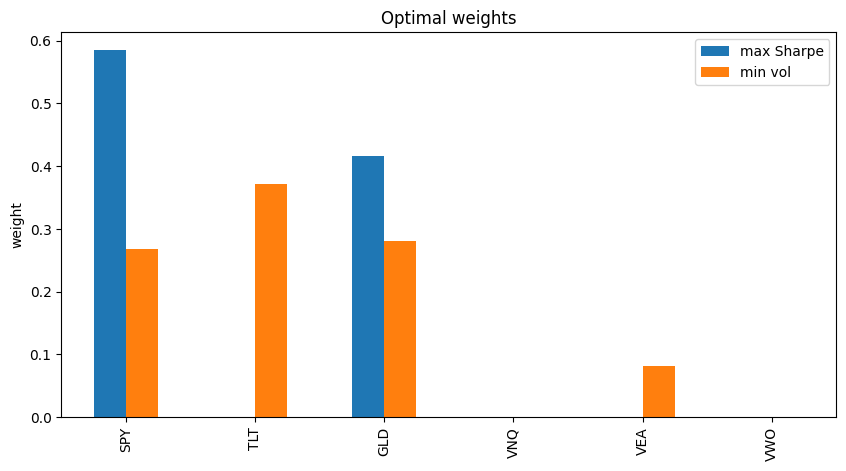

In [6]:
weights = pd.DataFrame({"max Sharpe": w_ms, "min vol": w_minvol})
print(weights.round(4))
weights.plot.bar(title="Optimal weights"); plt.ylabel("weight");

n_eff = 1 / (w_ms**2).sum()
print(f"\nmax-Sharpe holds {(w_ms > 1e-4).sum()} of {len(TICKERS)} assets"
      f"  ->  effective N = {n_eff:.2f}")

# same objective, Ledoit-Wolf covariance: watch the weights move
ef = EfficientFrontier(mu, S_lw)
ef.max_sharpe(risk_free_rate=RF)
print("\nmax Sharpe under Ledoit-Wolf covariance:")
print(pd.Series(ef.clean_weights()).round(4))

## 6 · In-sample performance (read the fine print)

Backtesting the max-Sharpe weights on the *same decade used to fit them* is not
a forecast — it is the optimiser grading its own homework. We plot it anyway,
because the comparison against equal-weight and SPY makes the in-sample flattery
visible and honest.

max Sharpe (in-sample)    296.3
equal weight              187.9
SPY                       339.6
Name: 2024-12-31 00:00:00, dtype: float64


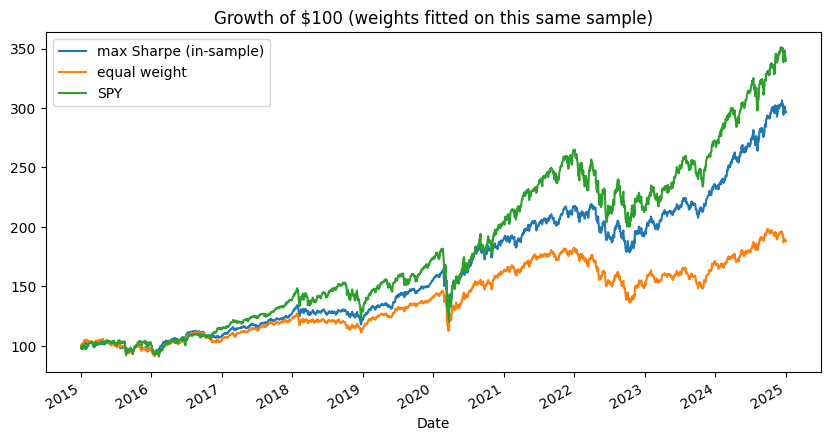

In [7]:
rets = px.pct_change().dropna()
w_eq = np.ones(len(TICKERS)) / len(TICKERS)

growth = pd.DataFrame({
    "max Sharpe (in-sample)": (1 + rets @ w_ms.values).cumprod(),
    "equal weight":           (1 + rets @ w_eq).cumprod(),
    "SPY":                    (1 + rets["SPY"]).cumprod(),
}) * 100
growth.plot(title="Growth of $100 (weights fitted on this same sample)");
print(growth.iloc[-1].round(1))

## Takeaways

- The frontier is the upper-left edge of everything attainable; with a
  risk-free asset it collapses to one tangency portfolio plus leverage.
- PyPortfolioOpt reduces the whole workflow to a few lines: estimators in,
  convex solver out.
- The max-Sharpe portfolio is concentrated — MVO amplifies estimation error
  in μ far more than diversification logic would suggest.
- Fixes are the next tutorials: shrink the covariance (Ledoit–Wolf), and
  discipline the return forecasts with priors (Black–Litterman, T06).

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*